<a href="https://colab.research.google.com/github/BrendJ510/Proyectos-Escolares/blob/main/Comparaci%C3%B3n_de_Modelos_de_Clasificaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelos de Clasificación

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
def plot_confusion_matrix(cm, labels):
    fig_cm = px.imshow(cm, labels=dict(x="Predicted", y="Actual", color="Count"),
                       x=labels, y=labels, color_continuous_scale='Viridis', text_auto = True,
                       title="Confusion Matrix")
    fig_cm.update_layout(coloraxis_showscale=False)
    fig_cm.show()

In [ ]:

mypath = "/content/pima-indians-diabetes.csv"

data = pd.read_csv(mypath, sep=",")
data.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
data.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0


In [ ]:
X = data[data.columns[:-1]]
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,1,85,66,29,0,26.6,0.351,31
1,8,183,64,0,0,23.3,0.672,32
2,1,89,66,23,94,28.1,0.167,21
3,0,137,40,35,168,43.1,2.288,33
4,5,116,74,0,0,25.6,0.201,30


In [ ]:
Y = data['Outcome']
Y.head()

,Outcome
0,0
1,1
2,0
3,1
4,0


In [ ]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, Y, train_size = 0.75,
                                                random_state = 31)

## Regresión Logistica

In [ ]:
modelo_LR = LogisticRegression(max_iter = 1000).fit(Xtrain, ytrain)
modelo_LR

LogisticRegression(max_iter=1000)

In [ ]:
pred = modelo_LR.predict(Xtest)
pred

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
lr_accuracy = accuracy_score(ytest, pred)
lr_accuracy

0.75

In [ ]:
lr_precision = precision_score(ytest, pred)
lr_precision

0.6031746031746031

In [ ]:
lr_recall = recall_score(ytest, pred)
lr_recall

0.6229508196721312

In [ ]:
lr_f1 = f1_score(ytest, pred)
lr_f1

0.6129032258064516

In [ ]:
lr_report = classification_report(ytest, pred)
print(lr_report)

              precision    recall  f1-score   support

           0       0.82      0.81      0.82       131
           1       0.60      0.62      0.61        61

    accuracy                           0.75       192
   macro avg       0.71      0.72      0.71       192
weighted avg       0.75      0.75      0.75       192



In [ ]:
lr_cm = confusion_matrix(ytest, pred)
plot_confusion_matrix(lr_cm, ['Sano', 'Enfermo'])

In [ ]:
lr_cm

array([[106,  25],
       [ 23,  38]])

In [ ]:
TPrate = lr_cm[1,1] / (lr_cm[1,0] + lr_cm[1,1])
TPrate

np.float64(0.6229508196721312)

In [ ]:
FPrate = lr_cm[0,1]/(lr_cm[0,0] + lr_cm[0,1])
FPrate

np.float64(0.19083969465648856)

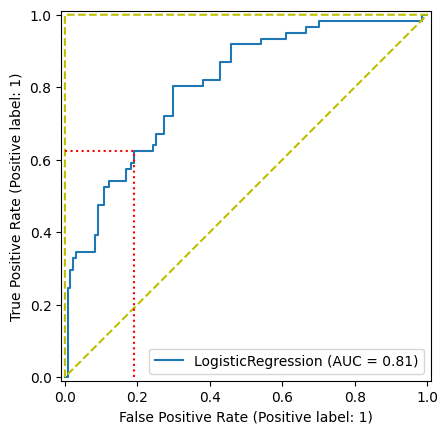

In [ ]:
RocCurveDisplay.from_estimator(modelo_LR, Xtest, ytest)
plt.plot([0,0,1,0], [0,1,1,0], 'y--')
plt.hlines(TPrate, 0, FPrate, colors = 'r', linestyles = 'dotted')
plt.vlines(FPrate, 0, TPrate, colors = 'r', linestyles = 'dotted')
plt.show()

## K-Means

In [ ]:
def plot_confusion_matrix(cm, labels):
    fig_cm = px.imshow(cm, labels=dict(x="Predicted", y="Actual", color="Count"),
                       x=labels, y=labels, color_continuous_scale='Viridis', text_auto = True,
                       title="Confusion Matrix")
    fig_cm.update_layout(coloraxis_showscale=False)
    fig_cm.show()

In [ ]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, Y, train_size = 0.75,
                                                random_state = 31)

In [ ]:
Y.value_counts()

,count
Outcome,
0,500
1,267


In [ ]:
Counter(Y)

Counter({0: 500, 1: 267})

In [ ]:
ytrain.value_counts()

,count
Outcome,
0,369
1,206


In [ ]:
Modelo_KNN=KNeighborsClassifier().fit(Xtrain,ytrain)
Modelo_KNN

KNeighborsClassifier()

In [ ]:
pred_knn = Modelo_KNN.predict(Xtest)
pred_knn

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1])

In [ ]:
knn_accuracy =accuracy_score(ytest,pred_knn)
knn_accuracy

0.703125

In [ ]:
knn_precision = precision_score(ytest,pred_knn)
knn_precision

0.532258064516129

In [ ]:
knn_recall = recall_score(ytest,pred_knn)
knn_recall

0.5409836065573771

In [ ]:
knn_f1 = f1_score(ytest,pred_knn)
knn_f1

0.5365853658536586

In [ ]:
knn_report = classification_report(ytest,pred_knn)
print(knn_report)

              precision    recall  f1-score   support

           0       0.78      0.78      0.78       131
           1       0.53      0.54      0.54        61

    accuracy                           0.70       192
   macro avg       0.66      0.66      0.66       192
weighted avg       0.70      0.70      0.70       192



In [ ]:
knn_cm=confusion_matrix(ytest,pred_knn)
plot_confusion_matrix(knn_cm,['Sano','Enfermo'])

In [ ]:
knn_cm

array([[102,  29],
       [ 28,  33]])

In [ ]:
TPrate = knn_cm[1,1]/(knn_cm[1,0]+knn_cm[1,1])
TPrate #falso positivo

np.float64(0.5409836065573771)

In [ ]:
FPrate = knn_cm[0,1]/(knn_cm[0,0]+knn_cm[0,1])
FPrate #falso negativo

np.float64(0.22137404580152673)

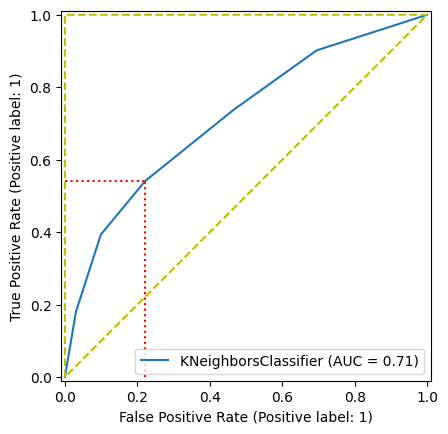

In [ ]:
RocCurveDisplay.from_estimator(Modelo_KNN,Xtest,ytest)
plt.plot([0,0,1,0],[0,1,1,0],'y--')
plt.hlines(TPrate, 0, FPrate, color='r', linestyle='dotted')
plt.vlines(FPrate, 0,TPrate, color='r', linestyle='dotted')
plt.show()

## SVM

In [ ]:
X = data[data.columns[:-1]]
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,1,85,66,29,0,26.6,0.351,31
1,8,183,64,0,0,23.3,0.672,32
2,1,89,66,23,94,28.1,0.167,21
3,0,137,40,35,168,43.1,2.288,33
4,5,116,74,0,0,25.6,0.201,30


In [ ]:
Y = data['Outcome']
Y.head()

,Outcome
0,0
1,1
2,0
3,1
4,0


In [ ]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, Y, train_size=0.75, random_state=31)
print(Xtrain.shape)
print(Xtest.shape)
print(ytrain.shape)
print(ytest.shape)

(575, 8)
(192, 8)
(575,)
(192,)


In [ ]:
svm = SVC()
svm.fit(Xtrain, ytrain)
svm

SVC()

In [ ]:
pred_svm = svm.predict(Xtest)
pred_svm

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
svm_accuracy = accuracy_score(ytest, pred_svm)
svm_accuracy

0.7552083333333334

In [ ]:

svm_precision = precision_score(ytest, pred_svm)
svm_precision

0.64

In [ ]:
svm_recall = recall_score(ytest, pred_svm)
svm_recall

0.5245901639344263

In [ ]:
svm_f1 = f1_score(ytest, pred_svm)
svm_f1

0.5765765765765766

In [ ]:
svm_report = classification_report(ytest, pred_svm)
print(svm_report)

              precision    recall  f1-score   support

           0       0.80      0.86      0.83       131
           1       0.64      0.52      0.58        61

    accuracy                           0.76       192
   macro avg       0.72      0.69      0.70       192
weighted avg       0.75      0.76      0.75       192



In [ ]:
svm_cm = confusion_matrix(ytest, pred_svm)
plot_confusion_matrix(svm_cm, ['Sano','Diabetes'])

In [ ]:
svm_cm

array([[113,  18],
       [ 29,  32]])

In [ ]:
TPrate = svm_cm[1,1] / (svm_cm[1,0] + svm_cm[1,1])
TPrate

np.float64(0.5245901639344263)

In [ ]:
FPrate = svm_cm[0,1] / (svm_cm[0,0] + svm_cm[0,1])
FPrate

np.float64(0.13740458015267176)

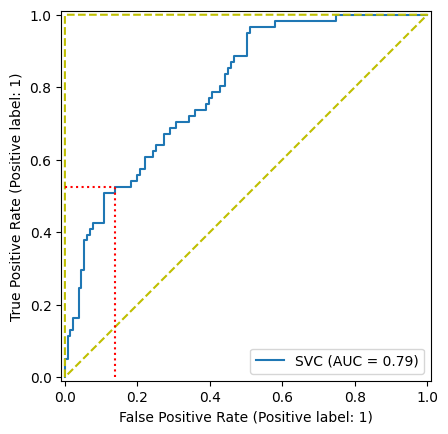

In [ ]:
RocCurveDisplay.from_estimator(svm, Xtest, ytest)
plt.plot([0,0,1,0], [0,1,1,0], 'y--')
plt.plot([FPrate, FPrate], [0, TPrate], color = 'r', linestyle = 'dotted')
plt.plot([0, FPrate], [TPrate, TPrate], color = 'r', linestyle = 'dotted')
plt.show()

## Naives Bayes

In [ ]:
nb = GaussianNB()
nb.fit(Xtrain, ytrain)

GaussianNB()

In [ ]:
nb_pred = nb.predict(Xtest)

In [ ]:
nb_accuracy = accuracy_score(ytest, nb_pred)
print(f"Naive Bayes Accuracy: {nb_accuracy:.2f}")

Naive Bayes Accuracy: 0.73


In [ ]:
nb_precision = precision_score(ytest, nb_pred)
print(f"Naive Bayes Precission: {nb_precision:.2f}")

Naive Bayes Precission: 0.56


In [ ]:
nb_recall = recall_score(ytest, nb_pred)
print(f"Naive Bayes Recall: {nb_recall:.2f}")

Naive Bayes Recall: 0.66


In [ ]:
nb_f1 = f1_score(ytest, nb_pred)
print(f"Naive Bayes F1 Score: {nb_f1:.2f}")

Naive Bayes F1 Score: 0.61


In [ ]:
nb_report = classification_report(ytest, nb_pred)
print("Naive Bayes Classification Report:")
print(nb_report)

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.76      0.79       131
           1       0.56      0.66      0.61        61

    accuracy                           0.73       192
   macro avg       0.69      0.71      0.70       192
weighted avg       0.74      0.73      0.73       192



In [ ]:
nb_cm = confusion_matrix(ytest, nb_pred)
plot_confusion_matrix(nb_cm, ['Sano', 'Enfermo'])

In [ ]:
nb_cm

array([[100,  31],
       [ 21,  40]])

In [ ]:
TPrate = nb_cm[1,1] / (nb_cm[1,0] + nb_cm[1,1])
TPrate

np.float64(0.6557377049180327)

In [ ]:
FPrate = nb_cm[0,1] / (nb_cm[0,0] + nb_cm[0,1])
FPrate

np.float64(0.2366412213740458)

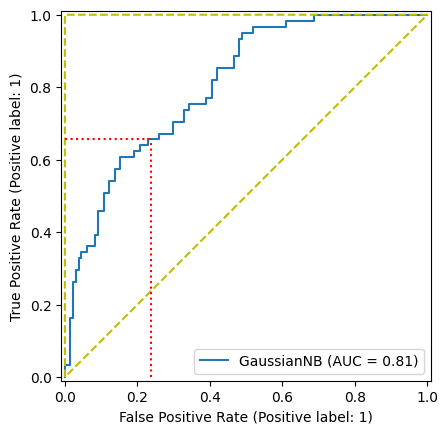

In [ ]:
RocCurveDisplay.from_estimator(nb, Xtest, ytest)
plt.plot([0,0,1,0], [0,1,1,0], 'y--')
plt.plot([FPrate, FPrate], [0, TPrate], color = 'r', linestyle = 'dotted')
plt.plot([0, FPrate], [TPrate, TPrate], color = 'r', linestyle = 'dotted')
plt.show()

## Árboles de Decisión / Bosques Aleatorios

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(Xtrain)
X_test_scaled = scaler.transform(Xtest)

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train_scaled, ytrain)

DecisionTreeClassifier()

In [ ]:
dt_pred = dt.predict(X_test_scaled)
dt_pred

array([0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1])

In [ ]:
dt_accuracy = accuracy_score(ytest, dt_pred)
dt_accuracy

0.734375

In [ ]:
dt_precision = precision_score(ytest, dt_pred)
dt_precision

0.5694444444444444

In [ ]:
dt_recall = recall_score(ytest, dt_pred)
dt_recall

0.6721311475409836

In [ ]:
dt_f1 = f1_score(ytest, dt_pred)
dt_f1

0.6165413533834586

In [ ]:
dt_report = classification_report(ytest, dt_pred)
print(dt_report)

              precision    recall  f1-score   support

           0       0.83      0.76      0.80       131
           1       0.57      0.67      0.62        61

    accuracy                           0.73       192
   macro avg       0.70      0.72      0.71       192
weighted avg       0.75      0.73      0.74       192



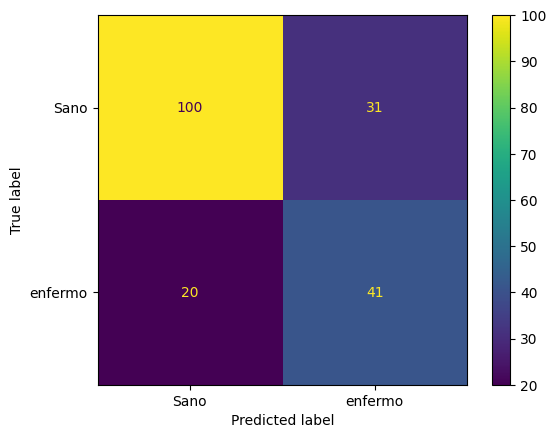

In [ ]:
dt_cm = confusion_matrix(ytest, dt_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=dt_cm, display_labels=['Sano', 'enfermo'])
disp.plot()
plt.show()

In [ ]:
TPrate = dt_cm[1,1] / (dt_cm[1,0] + dt_cm[1,1])
TPrate

np.float64(0.6721311475409836)

In [ ]:
FPrate = dt_cm[0,1] / (dt_cm[0,0] + dt_cm[0,1])
FPrate

np.float64(0.2366412213740458)

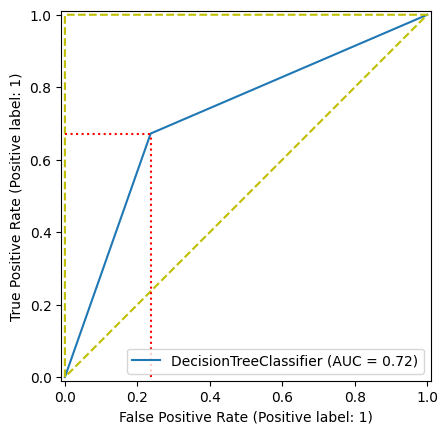

In [ ]:
RocCurveDisplay.from_estimator(dt, X_test_scaled, ytest)
plt.plot([0,0,1,0], [0,1,1,0], 'y--')
plt.plot([FPrate, FPrate], [0, TPrate], color = 'r', linestyle = 'dotted')
plt.plot([0, FPrate], [TPrate, TPrate], color = 'r', linestyle = 'dotted')
plt.show()

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train_scaled, ytrain)

RandomForestClassifier()

In [ ]:
rf_pred=rf.predict(X_test_scaled)
rf_pred

array([0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1])

In [ ]:
rf_accuracy = accuracy_score(ytest, rf_pred)
rf_accuracy

0.7604166666666666

In [ ]:
rf_precision = precision_score(ytest, rf_pred)
rf_precision

0.6153846153846154

In [ ]:
rf_recall= recall_score(ytest,rf_pred)
rf_recall

0.6557377049180327

In [ ]:
rf_f1=f1_score(ytest,rf_pred)
rf_f1

0.6349206349206349

In [ ]:
rf_report= classification_report(ytest,rf_pred)
print(rf_report)

              precision    recall  f1-score   support

           0       0.83      0.81      0.82       131
           1       0.62      0.66      0.63        61

    accuracy                           0.76       192
   macro avg       0.73      0.73      0.73       192
weighted avg       0.76      0.76      0.76       192



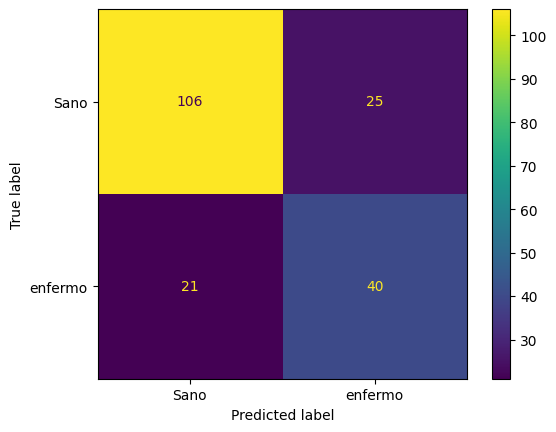

In [ ]:
rf_cm = confusion_matrix(ytest, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=['Sano', 'enfermo'])
disp.plot()
plt.show()

In [ ]:
TPrate = rf_cm[1,1] / (rf_cm[1,0] + rf_cm[1,1])
TPrate

np.float64(0.6557377049180327)

In [ ]:
FPrate = rf_cm[0,1] / (rf_cm[0,0] + rf_cm[0,1])
FPrate

np.float64(0.19083969465648856)

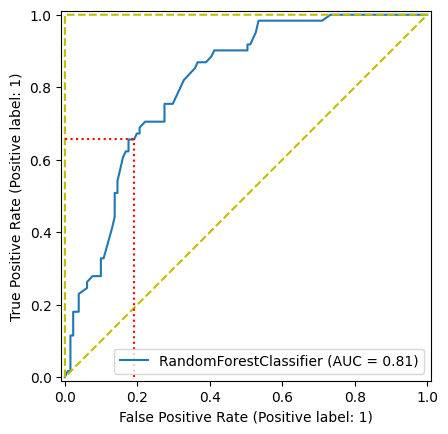

In [ ]:
RocCurveDisplay.from_estimator(rf, X_test_scaled, ytest)
plt.plot([0,0,1,0], [0,1,1,0], 'y--')
plt.plot([FPrate, FPrate], [0, TPrate], color = 'r', linestyle = 'dotted')
plt.plot([0, FPrate], [TPrate, TPrate], color = 'r', linestyle = 'dotted')
plt.show()

### Datos sin escalar

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(Xtrain, ytrain)

DecisionTreeClassifier()

In [ ]:
dt_pred = dt.predict(Xtest)
dt_pred

array([0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1])

In [ ]:
dt_accuracy = accuracy_score(ytest, dt_pred)
dt_accuracy

0.7447916666666666

In [ ]:
dt_precision = precision_score(ytest, dt_pred)
dt_precision

0.581081081081081

In [ ]:
dt_recall = recall_score(ytest, dt_pred)
dt_recall

0.7049180327868853

In [ ]:
dt_f1 = f1_score(ytest, dt_pred)
dt_f1

0.6370370370370371

In [ ]:
dt_report = classification_report(ytest, dt_pred)
print(dt_report)

              precision    recall  f1-score   support

           0       0.85      0.76      0.80       131
           1       0.58      0.70      0.64        61

    accuracy                           0.74       192
   macro avg       0.71      0.73      0.72       192
weighted avg       0.76      0.74      0.75       192



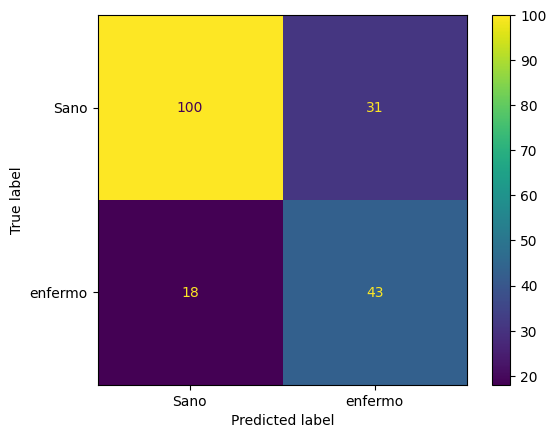

In [ ]:
dt_cm = confusion_matrix(ytest, dt_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=dt_cm, display_labels=['Sano', 'enfermo'])
disp.plot()
plt.show()

In [ ]:
TPrate = dt_cm[1,1] / (dt_cm[1,0] + dt_cm[1,1])
TPrate

np.float64(0.7049180327868853)

In [ ]:
FPrate = dt_cm[0,1] / (dt_cm[0,0] + dt_cm[0,1])
FPrate

np.float64(0.2366412213740458)

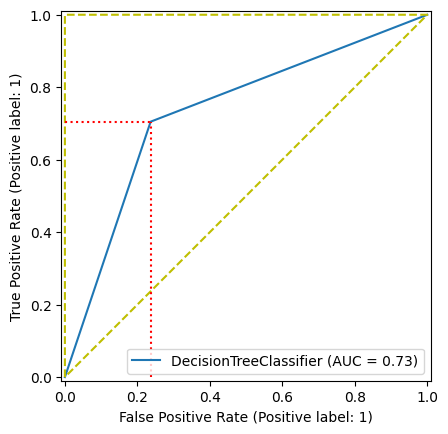

In [ ]:
RocCurveDisplay.from_estimator(dt, Xtest, ytest)
plt.plot([0,0,1,0], [0,1,1,0], 'y--')
plt.plot([FPrate, FPrate], [0, TPrate], color = 'r', linestyle = 'dotted')
plt.plot([0, FPrate], [TPrate, TPrate], color = 'r', linestyle = 'dotted')
plt.show()

In [ ]:
rf = RandomForestClassifier()
rf.fit(Xtrain, ytrain)

RandomForestClassifier()

In [ ]:
rf_pred=rf.predict(Xtest)
rf_pred

array([0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1])

In [ ]:
rf_accuracy = accuracy_score(ytest, rf_pred)
rf_accuracy

0.7760416666666666

In [ ]:
rf_precision = precision_score(ytest, rf_pred)
rf_precision

0.640625

In [ ]:
rf_recall= recall_score(ytest,rf_pred)
rf_recall

0.6721311475409836

In [ ]:
rf_f1=f1_score(ytest,rf_pred)
rf_f1

0.656

In [ ]:
rf_report= classification_report(ytest,rf_pred)
print(rf_report)

              precision    recall  f1-score   support

           0       0.84      0.82      0.83       131
           1       0.64      0.67      0.66        61

    accuracy                           0.78       192
   macro avg       0.74      0.75      0.74       192
weighted avg       0.78      0.78      0.78       192



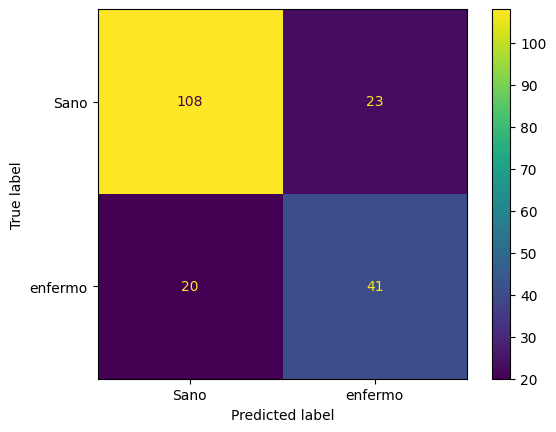

In [ ]:
rf_cm = confusion_matrix(ytest, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=['Sano', 'enfermo'])
disp.plot()
plt.show()

In [ ]:
TPrate = rf_cm[1,1] / (rf_cm[1,0] + rf_cm[1,1])
TPrate

np.float64(0.6721311475409836)

In [ ]:
FPrate = rf_cm[0,1] / (rf_cm[0,0] + rf_cm[0,1])
FPrate

np.float64(0.17557251908396945)

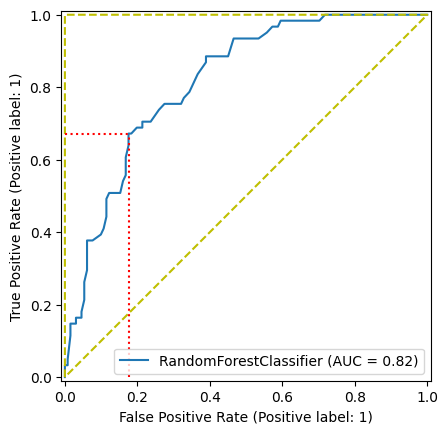

In [ ]:
RocCurveDisplay.from_estimator(rf, Xtest, ytest)
plt.plot([0,0,1,0], [0,1,1,0], 'y--')
plt.plot([FPrate, FPrate], [0, TPrate], color = 'r', linestyle = 'dotted')
plt.plot([0, FPrate], [TPrate, TPrate], color = 'r', linestyle = 'dotted')
plt.show()

## Comparación de los Modelos

##Accuracy

In [ ]:
list = [lr_accuracy, knn_accuracy, svm_accuracy, nb_accuracy, dt_accuracy, rf_accuracy]
score

## Precisión


## Recall

In [ ]:
models_data = {
    'Model': ['Logistic Regression', 'K-Nearest Neighbors', 'Support Vector Machine', 'Naive Bayes','Decision Tree', 'Random Forest'],
    'Recall': [lr_recall, knn_recall, svm_recall, nb_recall, dt_recall, rf_recall],
}

df_models = pd.DataFrame(models_data)
display(df_models)

In [ ]:
fig = px.bar(df_models, x='Model', y='Recall', color='Model', title='Recall Comparacion')
fig.show()

##F1-Score

In [ ]:
models_data = {
    'Model': ['Logistic Regression', 'K-Nearest Neighbors', 'Support Vector Machine', 'Naive Bayes','Decision Tree', 'Random Forest'],
    'Recall': [lr_f1, knn_f1, svm_f1, nb_f1, dt_f1, rf_f1],
}

df_models = pd.DataFrame(models_data)
display(df_models)

In [ ]:
fig = px.bar(df_models, x='Model', y='F1', color='Model', title='F1 Comparacion')
fig.show()